In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bcf_pressure_profile import HaloProfilePressureBFC
from params_bfc import par as default_par


from scipy.interpolate import RegularGridInterpolator
from integrator import HMCalculatorHarriet

import utils as ut
import pyccl as ccl
import pylab as plt
import matplotlib.cm as cm
from scipy.special import erf
%matplotlib inline

Baryonification

In [4]:


# nM = ccl.halos.MassFuncTinker08(mass_def="200c")
nM = ccl.halos.MassFuncBocquet20(mass_def="200c")
bM = ccl.halos.HaloBiasTinker10(mass_def="200c")
cM = ccl.halos.ConcentrationDuffy08(mass_def="200c")
mv2mt = ut.Mvir2MtotNFWt(concentration_f=cM)
pgas = ut.HaloProfileGasBFCDavid(mass_def="200c", log10Mc=8, mu=0.25, delta=2.0, Mvir2Mtot=mv2mt)


pmat = ccl.halos.HaloProfileNFW(mass_def="200c", concentration=cM, truncated=False)  #added truncated=False for halo particle plots

# Define new halo model calculator using the total mass as normalisation of the gas profile
hmc = ccl.halos.HMCalculator(mass_function=nM, halo_bias=bM, mass_def="200c",
                             log10M_min=10.0, log10M_max=15.0, nM=64)
hmch = HMCalculatorHarriet(mass_function=nM, halo_bias=bM, mass_def="200c",
                             log10M_min=10.0, log10M_max=15.0, nM=64)

# Create the Cosmology object
#D3A cosmology
cosmo_lcdm = ccl.Cosmology(Omega_c=0.2574,   # Cold dark matter density fraction
    Omega_b=0.0486,   # Baryon density fraction
    h=0.681,         # Hubble constant / 100
    #A_s=2.099e-9,     # Primordial amplitude
    n_s=0.967,     # Spectral index
    sigma8 = 0.8215942101867463
    )


#my values
#pgas_bfc = ut.HaloProfilePressureNFWBFCDavid(mass_def="200c", log10Mc=13.15, mu=0.75, delta=5, theta_c0=0.262, ciga0=0.122, Nstar=0.026, eta=0.066, deta=0.215, Mvir2Mtot=mv2mt)
#Michael's values
pgas_bfc = ut.HaloProfilePressureNFWBFCDavid(mass_def="200c", log10Mc=13.268, mu=0.755, delta=4.961, theta_c0=0.262, ciga0=0.122, Nstar=0.026, eta=0.066, deta=0.215,
                                             a0_nth=0.134, n_nth=0.35, b_nth=0.37, Mvir2Mtot=mv2mt)

pgas_bfc.update_precision_fftlog(padding_hi_fftlog=1E2,
                                     padding_lo_fftlog=1E-2,
                                     n_per_decade=500,
                                     plaw_fourier=-2.,
                                     large_padding_2D=True)




k_arr = np.geomspace(1E-5, 1E3, 500)
#k_arr = np.geomspace(1E-2, 1E1, 500)
lk_arr = np.log(k_arr)
z_arr = np.linspace(0, 2, 16)
a_arr = 1/(1+z_arr[::-1])

# matter-matter
# pk_mm_2h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pmat, prof2=pmat, get_1h=False)
# pk_mm_1h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pmat, prof2=pmat, get_2h=False)
# pk_mm = pk_mm_1h + pk_mm_2h 

#matter-gas
pk_mg_2h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmch, k_arr, 1.0, pmat, prof2=pgas, get_1h=False)
pk_mg_1h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmch, k_arr, 1.0, pmat, prof2=pgas, get_2h=False)
pk_mg = pk_mg_1h + pk_mg_2h

#gas-gas
# pk_gg_2h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pgas, prof2=pgas, get_1h=False)
# pk_gg_1h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pgas, prof2=pgas, get_2h=False)
# pk_gg = pk_gg_1h + pk_gg_2h

# pressure BFC
# pk_mg_bfc_2h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pmat, prof2=pgas_bfc, get_1h=False)
# pk_mg_bfc_1h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pmat, prof2=pgas_bfc, get_2h=False)
# pk_mg_bfc = pk_mg_bfc_2h + pk_mg_bfc_1h



Halo Density Profile

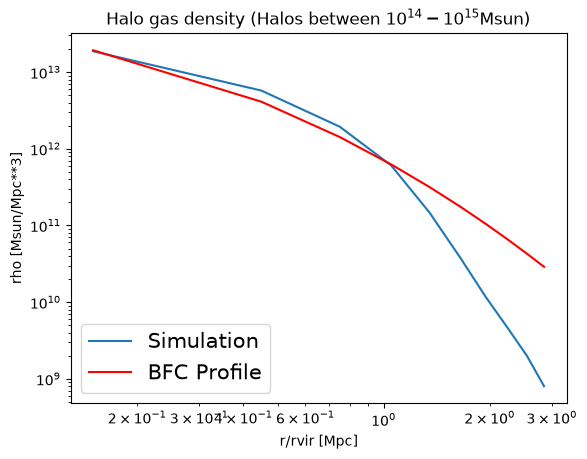

In [ ]:
import unyt

averages = np.load("halo_density_average.npy")

r_max = 5.0*unyt.Mpc 
r = np.linspace(0.01 * unyt.Mpc, r_max, 1000)
r = np.asarray(r)
averages = np.asarray(averages)

bin1 = np.load('bin_average_mass_10_to_11_bounded.npy')
bin2 = np.load('bin_average_mass_11_to_12_bounded.npy')
bin3 = np.load('bin_average_mass_12_to_13_bounded.npy')
bin4 = np.load('bin_average_mass_13_to_14_bounded.npy')
bin5 = np.load('bin_average_mass_14_to_15_bounded.npy')

bin1 = np.asarray(bin1)
bin2 = np.asarray(bin2)
bin3 = np.asarray(bin3)
bin4 = np.asarray(bin4)
bin5 = np.asarray(bin5)


r1 = np.load("r_array_mass_10_to_11_bounded.npy")
r2 = np.load("r_array_mass_11_to_12_bounded.npy")
r3 = np.load("r_array_mass_12_to_13_bounded.npy")
r4 = np.load("r_array_mass_13_to_14_bounded.npy")
r5 = np.load("r_array_mass_14_to_15_bounded.npy")

r_current = r5
x_edges = np.linspace(0, 3, len(r_current)+1)
x_mid = 0.5*(x_edges[1:]+x_edges[:-1])

# plt.plot(x_mid, bin1, label="$10^{10} - 10^{11}$")
# plt.plot(x_mid, bin2, label="$10^{11} - 10^{12}$")
# plt.plot(x_mid, bin3, label="$10^{12} - 10^{13}$")
# plt.plot(x_mid, bin4, label="$10^{13} - 10^{14}$")
# plt.plot(x_mid, bin5, label="$10^{14} - 10^{15}$")
plt.plot(x_mid, bin5, label="Simulation")




a = 1.0
M1 = 1E14
M2 = 1E15
Masses = np.geomspace(M1, M2, 20)
hmf = nM(cosmo_lcdm, Masses, a)
densities = []
densities_gas = []
for M in Masses:
    R = pmat.mass_def.get_radius(cosmo_lcdm, M, a) / a
    P = pmat._real(cosmo_lcdm, x_mid*R, M, a=1.0)
    Omega_b = cosmo_lcdm["Omega_b"]
    Omega_m = cosmo_lcdm["Omega_m"]
    f_gas = Omega_b / Omega_m
    P = P * f_gas
    densities.append(P)
    Pg = pgas._real(cosmo_lcdm, x_mid*R, M, a=1.0)
    densities_gas.append(Pg)
densities = np.array(densities)
density_ccl = np.sum(densities*hmf[:, None], axis=0)/np.sum(hmf)
densities_gas = np.array(densities_gas)
density_gas_ccl = np.sum(densities_gas*hmf[:, None], axis=0)/np.sum(hmf)


plt.plot(x_mid, density_gas_ccl, 'r-', label="BFC Profile")



plt.xlabel("r/rvir [Mpc]")
plt.ylabel("rho [Msun/Mpc**3]")
plt.title("Halo gas density (Halos between $10^{14}-10^{15}$Msun)")
plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=15)
plt.show()

Electron Pressure Profile

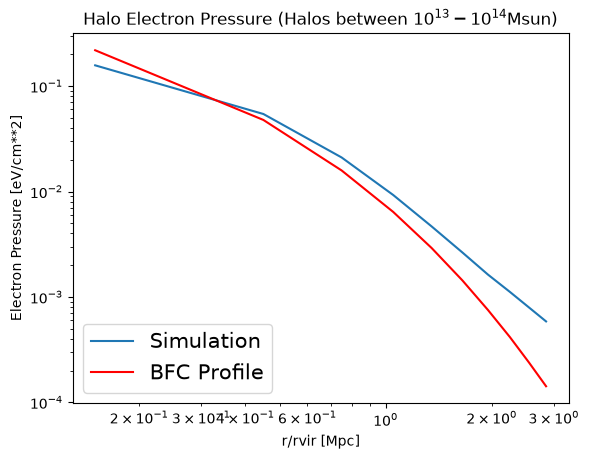

In [ ]:

r_max = 5.0*unyt.Mpc 
r = np.linspace(0.01 * unyt.Mpc, r_max, 1000)
r = np.asarray(r)
averages = np.asarray(averages)

bin1 = np.load('bin_average_pressure_10_to_11.npy')
bin2 = np.load('bin_average_pressure_11_to_12.npy')
bin3 = np.load('bin_average_pressure_12_to_13.npy')
bin4 = np.load('bin_average_pressure_13_to_14.npy')
bin5 = np.load('bin_average_pressure_14_to_15.npy')

bin1 = np.asarray(bin1)
bin2 = np.asarray(bin2)
bin3 = np.asarray(bin3)
bin4 = np.asarray(bin4)
bin5 = np.asarray(bin5)


r1 = np.load("r_array_pressure_10_to_11.npy")
r2 = np.load("r_array_pressure_11_to_12.npy")
r3 = np.load("r_array_pressure_12_to_13.npy")
r4 = np.load("r_array_pressure_13_to_14.npy")
r5 = np.load("r_array_pressure_14_to_15.npy")


# plt.plot(r1, bin1, label="$10^{10} - 10^{11}$")
# plt.plot(r2, bin2, label="$10^{11} - 10^{12}$")
# plt.plot(r3, bin3, label="$10^{12} - 10^{13}$")
# plt.plot(r4, bin4, label="$10^{13} - 10^{14}$")
# plt.plot(r5, bin5, label="$10^{14} - 10^{15}$")
plt.plot(r4, bin4, label="Simulation")


a = 1.0
M1 = 1E13
M2 = 1E14
Masses = np.geomspace(M1, M2, 20)
hmf = nM(cosmo_lcdm, Masses, a)
Pressures = []
for M in Masses:
    R = pgas_bfc.mass_def.get_radius(cosmo_lcdm, M, a) / a
    P = pgas_bfc._real(cosmo_lcdm, r4*R, M, a=1.0)
    Pressures.append(P)
Pressures = np.array(Pressures)
Pressure_ccl = np.sum(Pressures*hmf[:, None], axis=0)/np.sum(hmf)


plt.plot(r4, Pressure_ccl, 'r-', label="BFC Profile")


plt.xlabel("r/rvir [Mpc]")
plt.ylabel("Electron Pressure [eV/cm**2]")
plt.title("Halo Electron Pressure (Halos between $10^{13}-10^{14}$Msun)")
plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=15)
plt.show()

X-ray emissivity profile

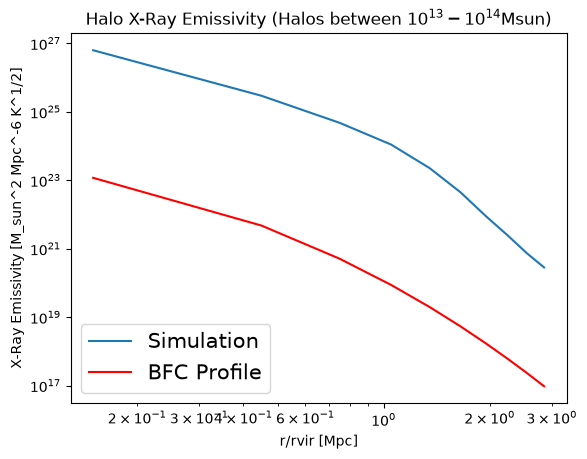

In [ ]:
r_max = 5.0*unyt.Mpc 
r = np.linspace(0.01 * unyt.Mpc, r_max, 1000)
r = np.asarray(r)
averages = np.asarray(averages)

bin1 = np.load('bin_average_dens_temp_10_to_11.npy')
bin2 = np.load('bin_average_dens_temp_11_to_12.npy')
bin3 = np.load('bin_average_dens_temp_12_to_13.npy')
bin4 = np.load('bin_average_dens_temp_13_to_14.npy')
bin5 = np.load('bin_average_dens_temp_14_to_15.npy')

bin1 = np.asarray(bin1)
bin2 = np.asarray(bin2)
bin3 = np.asarray(bin3)
bin4 = np.asarray(bin4)
bin5 = np.asarray(bin5)


r1 = np.load("r_array_dens_temp_10_to_11.npy")
r2 = np.load("r_array_dens_temp_11_to_12.npy")
r3 = np.load("r_array_dens_temp_12_to_13.npy")
r4 = np.load("r_array_dens_temp_13_to_14.npy")
r5 = np.load("r_array_dens_temp_14_to_15.npy")

r_current = r4
x_edges = np.linspace(0, 3, len(r_current)+1)
x_mid = 0.5*(x_edges[1:]+x_edges[:-1])


# plt.plot(r1, bin1, label="$10^{10} - 10^{11}$")
# plt.plot(r2, bin2, label="$10^{11} - 10^{12}$")
# plt.plot(r3, bin3, label="$10^{12} - 10^{13}$")
# plt.plot(r4, bin4, label="$10^{13} - 10^{14}$")
# plt.plot(r5, bin5, label="$10^{14} - 10^{15}$")
plt.plot(r4, bin4, label="Simulation")


a = 1.0
M1 = 1E13
M2 = 1E14
Masses = np.geomspace(M1, M2, 20)
hmf = nM(cosmo_lcdm, Masses, a)
plot_array = []
for M in Masses:
    R1 = pgas_bfc.mass_def.get_radius(cosmo_lcdm, M, a) / a
    P = pgas_bfc._real(cosmo_lcdm, x_mid*R, M, a=1.0)
    R2 = pmat.mass_def.get_radius(cosmo_lcdm, M, a) / a
    D = pgas._real(cosmo_lcdm, x_mid*R2, M, a=1.0) 
    Omega_b = cosmo_lcdm["Omega_b"]
    Omega_m = cosmo_lcdm["Omega_m"]
    f_gas = Omega_b / Omega_m
    #D = D / f_gas
    T = (P*2.63*1E7)/D
    result = D**2 * np.sqrt(T)
    plot_array.append(result)
plot_array = np.array(plot_array)
plot_array_dt = np.sum(plot_array*hmf[:, None], axis=0)/np.sum(hmf)


plt.plot(r4, plot_array_dt, 'r-', label="BFC Profile")


plt.xlabel("r/rvir [Mpc]")
plt.ylabel("X-Ray Emissivity [M_sun^2 Mpc^-6 K^1/2]")
plt.title("Halo X-Ray Emissivity (Halos between $10^{13}-10^{14}$Msun)")
plt.xscale('log')
plt.yscale('log')
plt.legend(loc='lower left', fontsize=15)
plt.show()